In [1]:
# 🧠 Brain Stroke CT Classification using 2D CNN
# --------------------------------------------------
import os
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import glob
from PIL import Image
import torchvision.models as models
from torchvision import transforms
from tqdm.notebook import tqdm
import random

In [2]:
# --------------------------------------------------
# 🌱 Set Random Seeds for Reproducibility
# --------------------------------------------------
def set_seed(seed=42):
    """
    Set random seeds for reproducibility across all libraries
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if using multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"Random seeds set to {seed} for reproducibility")

# Set random seeds
set_seed(42)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

Random seeds set to 42 for reproducibility


In [3]:
# --------------------------------------------------
# ✅ Dataset path and structure analysis
# --------------------------------------------------
dataset_path ="/kaggle/input/datasets/gauravdt035/brain-stroke-dataset/Brain_Stroke_CT_Dataset"

# Analyze dataset structure to understand what files are available
def analyze_dataset(root_dir):
    structure = {}
    for root, dirs, files in os.walk(root_dir):
        rel_dir = os.path.relpath(root, root_dir)
        if rel_dir == '.':
            continue
            
        # Count files by extension
        file_counts = {}
        for f in files:
            ext = os.path.splitext(f)[1].lower()
            if ext in file_counts:
                file_counts[ext] += 1
            else:
                file_counts[ext] = 1
                
        structure[rel_dir] = file_counts
        
    return structure

dataset_structure = analyze_dataset(dataset_path)
print("Dataset structure:")
for dir_path, file_types in dataset_structure.items():
    print(f"{dir_path}: {file_types}")

Dataset structure:
Ischemia: {}
Ischemia/DICOM: {'.dcm': 1130}
Ischemia/OVERLAY: {'.png': 2500}
Ischemia/PNG: {'.png': 2500}
Bleeding: {}
Bleeding/DICOM: {'.dcm': 1093}
Bleeding/OVERLAY: {'.png': 2500}
Bleeding/PNG: {'.png': 2500}
Normal: {}
Normal/DICOM: {'.dcm': 4427}
Normal/PNG: {'.png': 3183}
External_Test: {'.csv': 1}
External_Test/DICOM: {'.dcm': 200}
External_Test/OVERLAY: {'.png': 200}
External_Test/MASKS: {'.png': 200}
External_Test/PNG: {'.png': 200}


In [4]:
def load_image_paths(dataset_path):
    image_paths = []
    labels = []
    class_map = {'Normal': 0, 'Bleeding': 1, 'Ischemia': 2}
    
    # Standard images + DICOM
    valid_extensions = ('.png', '.jpg', '.jpeg', '.dcm')

    for class_name, label in class_map.items():
        class_folder = os.path.join(dataset_path, class_name)
        
        if os.path.exists(class_folder):
            # Use os.walk for more control over subfolders
            for root, dirs, files in os.walk(class_folder):
                # Optional: Skip OVERLAY folders if you don't want masks
                # if 'OVERLAY' in root: continue 
                
                for f in files:
                    if f.lower().endswith(valid_extensions):
                        image_paths.append(os.path.join(root, f))
                        labels.append(label)
        else:
            print(f"Warning: {class_folder} does not exist")
            
    return image_paths, labels

In [5]:
# Get image paths and labels
image_paths, labels = load_image_paths(dataset_path)
print(f"Found {len(image_paths)} images across {len(set(labels))} classes")

# Check class distribution
class_names = ['Normal', 'Bleeding', 'Ischemia']
label_counts = pd.Series(labels).value_counts().sort_index()
print("Class distribution:")
for i, count in enumerate(label_counts):
    print(f"{class_names[i]}: {count} images")

Found 19833 images across 3 classes
Class distribution:
Normal: 7610 images
Bleeding: 6093 images
Ischemia: 6130 images


In [6]:
!pip install pydicom

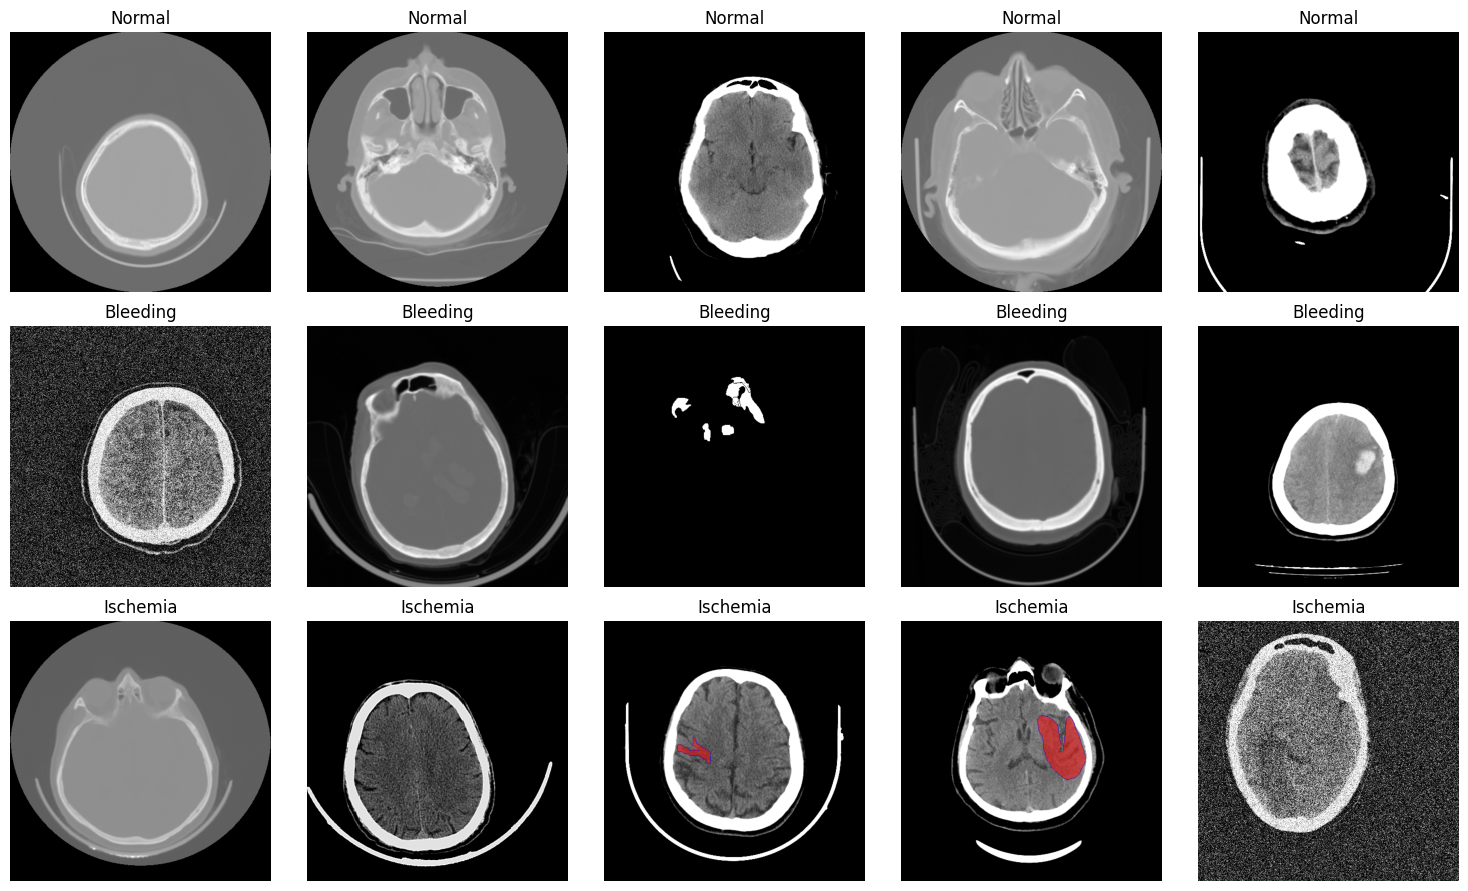

In [7]:
import pydicom
import numpy as np

def show_samples(image_paths, labels, n_samples=5):
    # 1. Get random indices for each class
    indices = {}
    class_names = ['Normal', 'Bleeding', 'Ischemia']
    
    for i in range(3):
        class_indices = [idx for idx, label in enumerate(labels) if label == i]
        if len(class_indices) >= n_samples:
            indices[i] = np.random.choice(class_indices, n_samples, replace=False)
        else:
            indices[i] = class_indices

    # 2. Create figure
    fig, axes = plt.subplots(3, n_samples, figsize=(15, 9))
    
    for i in range(3):
        for j in range(n_samples):
            if j < len(indices[i]):
                idx = indices[i][j]
                path = image_paths[idx]
                
                try:
                    if path.lower().endswith('.dcm'):
                        ds = pydicom.dcmread(path)
                        img = ds.pixel_array
                    else:
                        img = np.array(Image.open(path).convert('RGB'))
                    
                    # Display the image
                    axes[i, j].imshow(img, cmap='gray')
                    axes[i, j].set_title(f"{class_names[i]}")
                except Exception as e:
                    axes[i, j].set_title("Error")
            
            axes[i, j].axis('off')
            
    plt.tight_layout()
    plt.show() # <--- This is the most important line!

# Call the function to see the results
show_samples(image_paths, labels, n_samples=5)

In [8]:
# Split into train and validation sets
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Training set: {len(train_paths)} images")
print(f"Validation set: {len(val_paths)} images")

Training set: 15866 images
Validation set: 3967 images


In [9]:
import pydicom
from PIL import Image
import numpy as np

class BrainCTDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        try:
            # 1. Handle DICOM files
            if img_path.lower().endswith('.dcm'):
                ds = pydicom.dcmread(img_path)
                img = ds.pixel_array.astype(float)
                
                # Guard against division by zero if image is blank/black
                if img.max() > img.min():
                    img = (img - img.min()) / (img.max() - img.min()) * 255.0
                else:
                    img = np.zeros(img.shape) # Return black if no data
                
                img = Image.fromarray(img.astype(np.uint8)).convert('RGB')
            
            # 2. Handle standard PNG/JPG
            else:
                img = Image.open(img_path).convert('RGB')
                
        except Exception as e:
            # 3. Guard against corrupt files (returns a blank black image)
            # print(f"Warning: Skipping corrupt file {img_path}")
            img = Image.new('RGB', (224, 224), color='black')

        if self.transform:
            img = self.transform(img)
            
        return img, label

In [10]:
# Define transformations
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [11]:
# Create datasets
train_dataset = BrainCTDataset(train_paths, train_labels, transform=transform_train)
val_dataset = BrainCTDataset(val_paths, val_labels, transform=transform_val)

# Create data loaders
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# Check a batch of data
for images, labels in train_loader:
    print(f"Batch shape: {images.shape}")
    print(f"Labels shape: {labels.shape}")
    break


Batch shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])


In [12]:
# --------------------------------------------------
# 🔄 Model Setup (Improved with ResNeXt)
# --------------------------------------------------

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# Use a more powerful pre-trained ResNeXt model
# 1. Import the specific weights enum
from torchvision.models import ResNeXt50_32X4D_Weights

# 2. Load the model using the weights parameter
weights = ResNeXt50_32X4D_Weights.DEFAULT
model = models.resnext50_32x4d(weights=weights)

# Rest of your code remains the same
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 3)

# Modify the final fully connected layer for 3 classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 3)  # 3 classes: Normal, Bleeding, Ischemia

# Set device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model = model.to(device)

# Set up loss, optimizer, and learning rate scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, verbose=True)


Downloading: "https://download.pytorch.org/models/resnext50_32x4d-1a0047aa.pth" to /root/.cache/torch/hub/checkpoints/resnext50_32x4d-1a0047aa.pth
100%|██████████| 95.8M/95.8M [00:00<00:00, 213MB/s]


Using device: cuda


/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [13]:
# --------------------------------------------------
# 🏋️‍♀️ Training and Validation Functions
# --------------------------------------------------

def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, targets in tqdm(dataloader, desc="Training"):
        inputs, targets = inputs.to(device), targets.to(device)
        
        # Zero the parameter gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        # Track statistics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc

In [14]:
def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for inputs, targets in tqdm(dataloader, desc="Validating"):
            inputs, targets = inputs.to(device), targets.to(device)
            
            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            # Track statistics
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
            # Store predictions and targets for metrics
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc, all_preds, all_targets


In [15]:
# --------------------------------------------------
# 🏃‍♂️ Training Loop
# --------------------------------------------------

# Check if CUDA is available and set device accordingly
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Move model to device
model = model.to(device)

# Set training parameters
num_epochs = 20
best_val_acc = 0.0
train_losses, train_accs = [], []
val_losses, val_accs = [], []

# Start the training
print("Starting model training...")

Using device: cuda
Starting model training...



Epoch 1/20


Training:   0%|          | 0/992 [00:00<?, ?it/s]

Validating:   0%|          | 0/248 [00:00<?, ?it/s]

Train Loss: 0.6670, Train Acc: 0.7098
Val Loss: 0.7447, Val Acc: 0.6816
Saved new best model!

Classification Report:
              precision    recall  f1-score   support

      Normal       0.75      0.80      0.77      1522
    Bleeding       0.69      0.57      0.62      1219
    Ischemia       0.59      0.66      0.62      1226

    accuracy                           0.68      3967
   macro avg       0.68      0.67      0.67      3967
weighted avg       0.68      0.68      0.68      3967



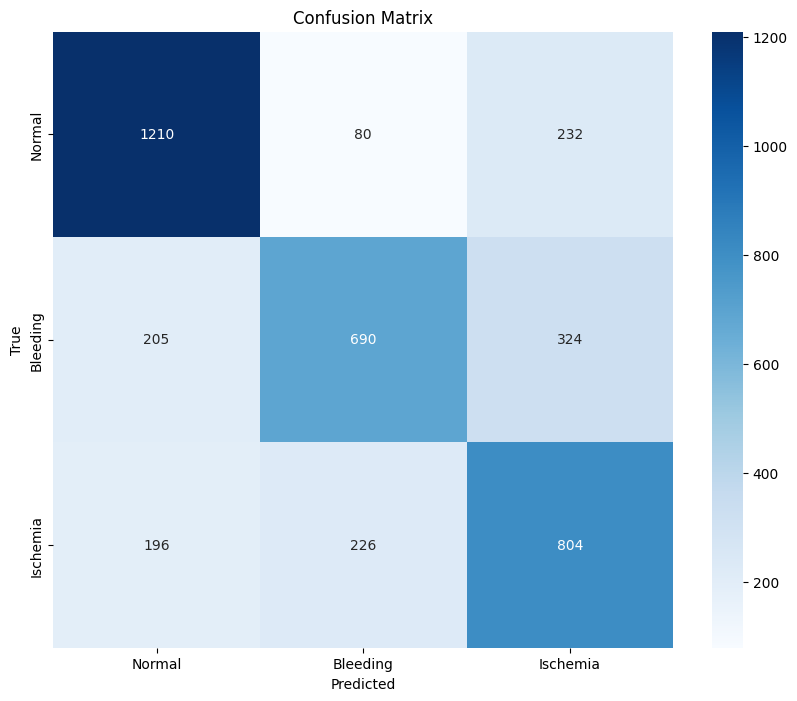


Epoch 2/20


Training:   0%|          | 0/992 [00:00<?, ?it/s]

Validating:   0%|          | 0/248 [00:00<?, ?it/s]

Train Loss: 0.5125, Train Acc: 0.7841
Val Loss: 0.4148, Val Acc: 0.8240
Saved new best model!

Classification Report:
              precision    recall  f1-score   support

      Normal       0.84      0.94      0.89      1522
    Bleeding       0.85      0.74      0.79      1219
    Ischemia       0.79      0.77      0.78      1226

    accuracy                           0.82      3967
   macro avg       0.82      0.81      0.82      3967
weighted avg       0.82      0.82      0.82      3967



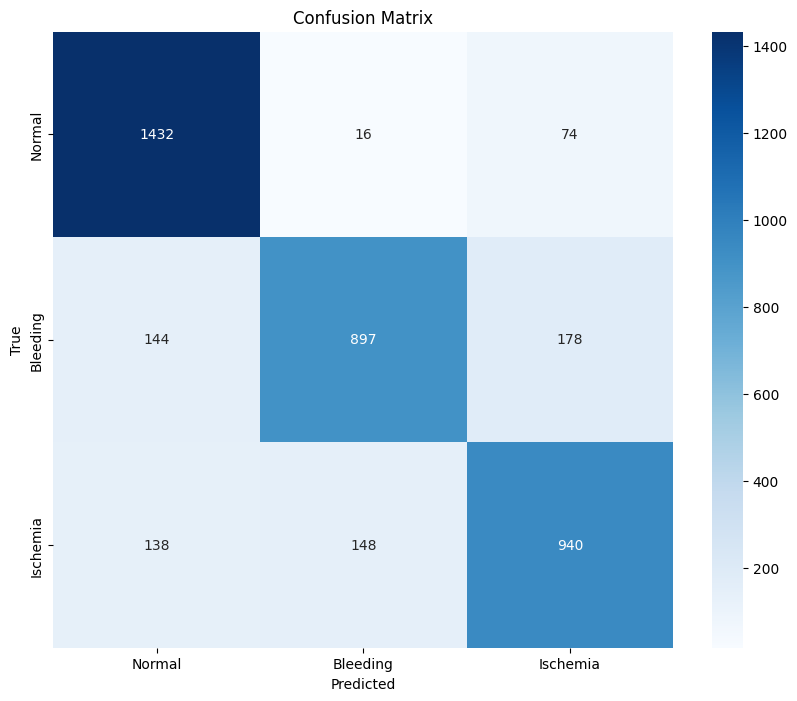


Epoch 3/20


Training:   0%|          | 0/992 [00:00<?, ?it/s]

Validating:   0%|          | 0/248 [00:00<?, ?it/s]

Train Loss: 0.4440, Train Acc: 0.8163
Val Loss: 0.3943, Val Acc: 0.8339
Saved new best model!

Classification Report:
              precision    recall  f1-score   support

      Normal       0.82      0.97      0.89      1522
    Bleeding       0.82      0.79      0.81      1219
    Ischemia       0.86      0.70      0.77      1226

    accuracy                           0.83      3967
   macro avg       0.84      0.82      0.83      3967
weighted avg       0.84      0.83      0.83      3967



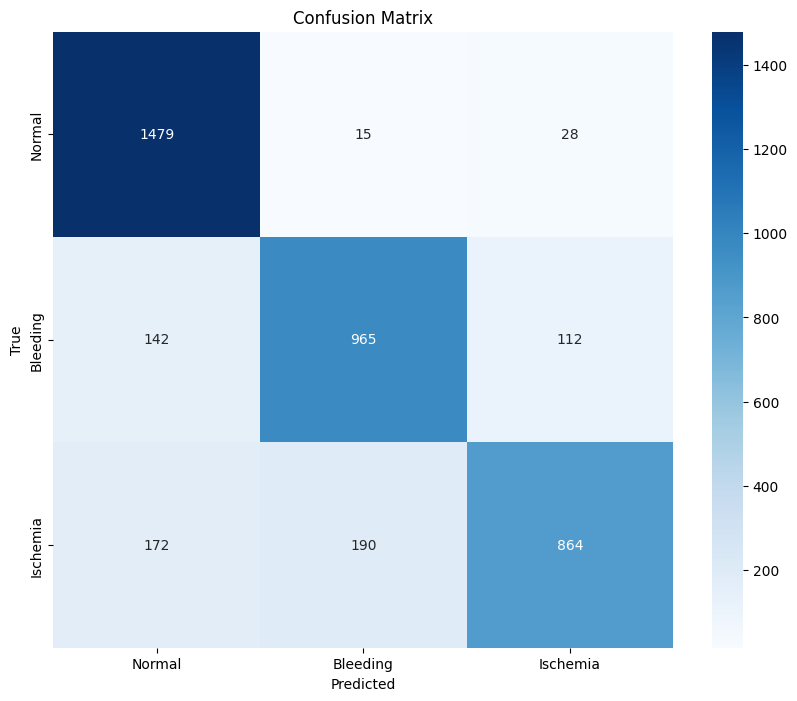


Epoch 4/20


Training:   0%|          | 0/992 [00:00<?, ?it/s]

Validating:   0%|          | 0/248 [00:00<?, ?it/s]

Train Loss: 0.4139, Train Acc: 0.8318
Val Loss: 0.3776, Val Acc: 0.8490
Saved new best model!

Classification Report:
              precision    recall  f1-score   support

      Normal       0.88      0.95      0.92      1522
    Bleeding       0.91      0.70      0.79      1219
    Ischemia       0.77      0.87      0.82      1226

    accuracy                           0.85      3967
   macro avg       0.85      0.84      0.84      3967
weighted avg       0.86      0.85      0.85      3967



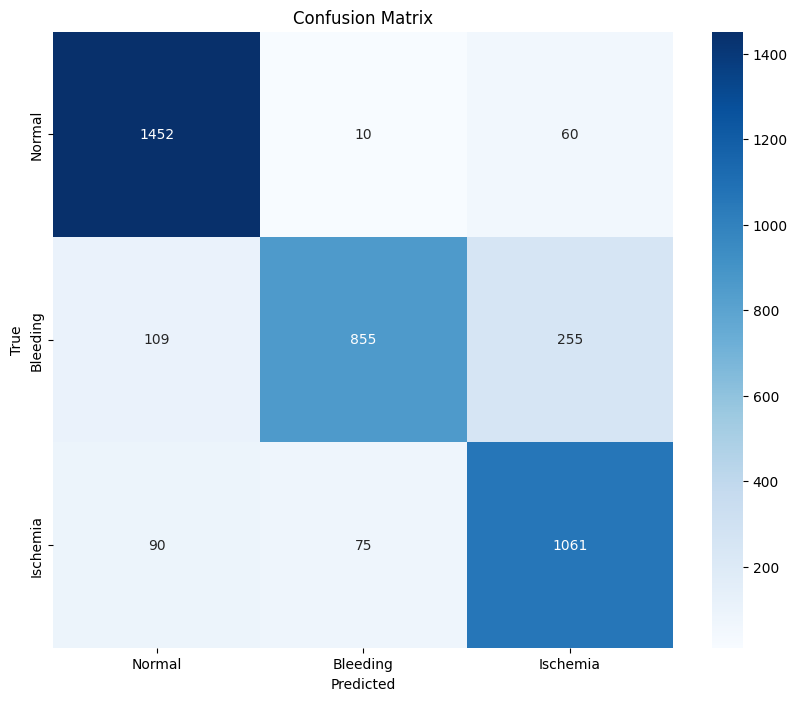


Epoch 5/20


Training:   0%|          | 0/992 [00:00<?, ?it/s]

Validating:   0%|          | 0/248 [00:00<?, ?it/s]

Train Loss: 0.3651, Train Acc: 0.8498
Val Loss: 0.3424, Val Acc: 0.8596
Saved new best model!

Classification Report:
              precision    recall  f1-score   support

      Normal       0.92      0.92      0.92      1522
    Bleeding       0.93      0.73      0.82      1219
    Ischemia       0.76      0.91      0.83      1226

    accuracy                           0.86      3967
   macro avg       0.87      0.85      0.85      3967
weighted avg       0.87      0.86      0.86      3967



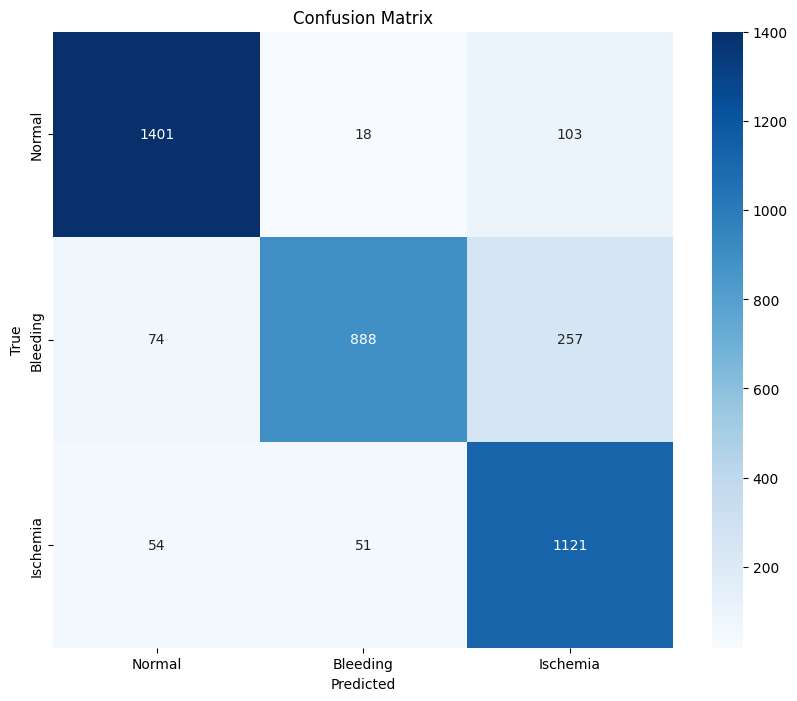


Epoch 6/20


Training:   0%|          | 0/992 [00:00<?, ?it/s]

Validating:   0%|          | 0/248 [00:00<?, ?it/s]

Train Loss: 0.3362, Train Acc: 0.8619
Val Loss: 0.3065, Val Acc: 0.8745
Saved new best model!

Classification Report:
              precision    recall  f1-score   support

      Normal       0.90      0.94      0.92      1522
    Bleeding       0.89      0.79      0.84      1219
    Ischemia       0.82      0.87      0.85      1226

    accuracy                           0.87      3967
   macro avg       0.87      0.87      0.87      3967
weighted avg       0.88      0.87      0.87      3967



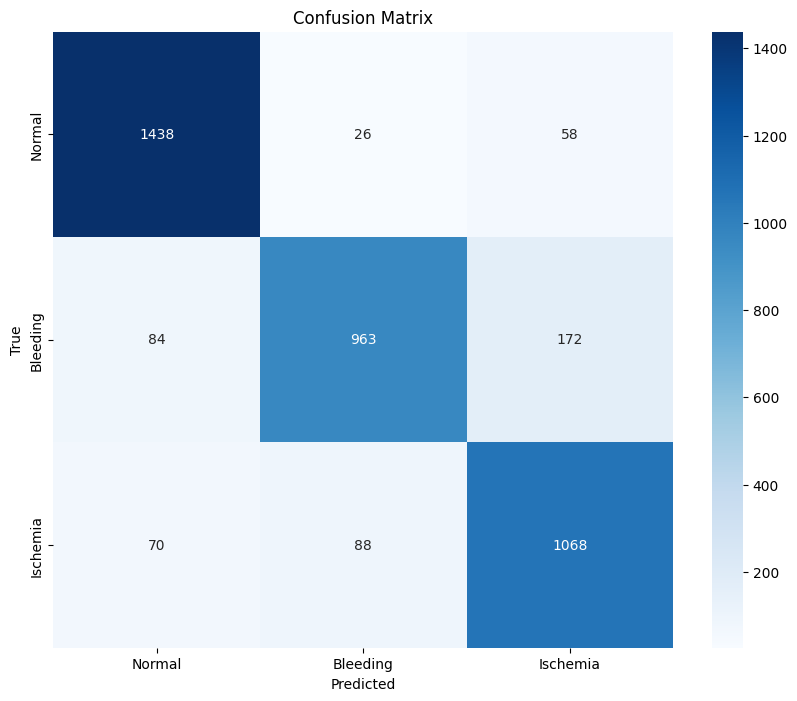


Epoch 7/20


Training:   0%|          | 0/992 [00:00<?, ?it/s]

Validating:   0%|          | 0/248 [00:00<?, ?it/s]

Train Loss: 0.3047, Train Acc: 0.8756
Val Loss: 0.2984, Val Acc: 0.8798
Saved new best model!

Classification Report:
              precision    recall  f1-score   support

      Normal       0.86      0.99      0.92      1522
    Bleeding       0.93      0.78      0.85      1219
    Ischemia       0.86      0.85      0.85      1226

    accuracy                           0.88      3967
   macro avg       0.89      0.87      0.87      3967
weighted avg       0.88      0.88      0.88      3967



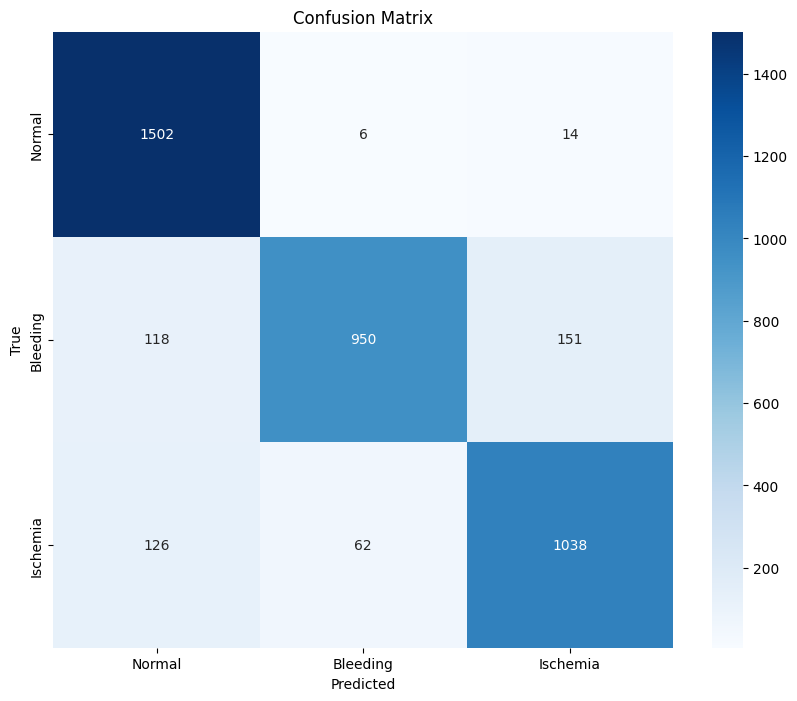


Epoch 8/20


Training:   0%|          | 0/992 [00:00<?, ?it/s]

Validating:   0%|          | 0/248 [00:00<?, ?it/s]

Train Loss: 0.2775, Train Acc: 0.8874
Val Loss: 0.2537, Val Acc: 0.8951
Saved new best model!

Classification Report:
              precision    recall  f1-score   support

      Normal       0.94      0.93      0.94      1522
    Bleeding       0.84      0.90      0.87      1219
    Ischemia       0.89      0.85      0.87      1226

    accuracy                           0.90      3967
   macro avg       0.89      0.89      0.89      3967
weighted avg       0.90      0.90      0.90      3967



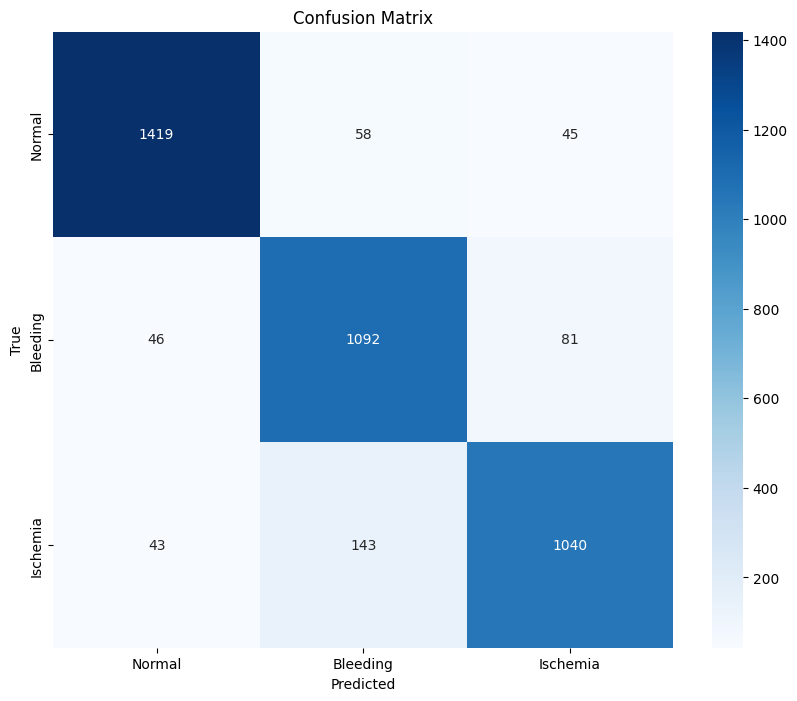


Epoch 9/20


Training:   0%|          | 0/992 [00:00<?, ?it/s]

Validating:   0%|          | 0/248 [00:00<?, ?it/s]

Train Loss: 0.2502, Train Acc: 0.8989
Val Loss: 0.2390, Val Acc: 0.9017
Saved new best model!

Classification Report:
              precision    recall  f1-score   support

      Normal       0.90      0.98      0.94      1522
    Bleeding       0.91      0.85      0.88      1219
    Ischemia       0.89      0.86      0.88      1226

    accuracy                           0.90      3967
   macro avg       0.90      0.90      0.90      3967
weighted avg       0.90      0.90      0.90      3967



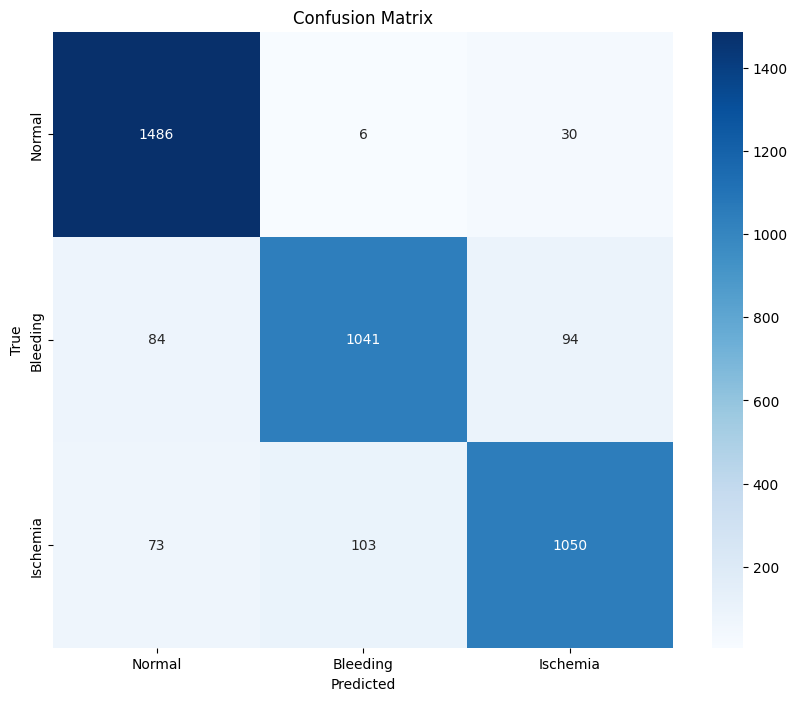


Epoch 10/20


Training:   0%|          | 0/992 [00:00<?, ?it/s]

Validating:   0%|          | 0/248 [00:00<?, ?it/s]

Train Loss: 0.2172, Train Acc: 0.9125
Val Loss: 0.1932, Val Acc: 0.9211
Saved new best model!

Classification Report:
              precision    recall  f1-score   support

      Normal       0.95      0.96      0.96      1522
    Bleeding       0.93      0.88      0.90      1219
    Ischemia       0.87      0.91      0.89      1226

    accuracy                           0.92      3967
   macro avg       0.92      0.92      0.92      3967
weighted avg       0.92      0.92      0.92      3967



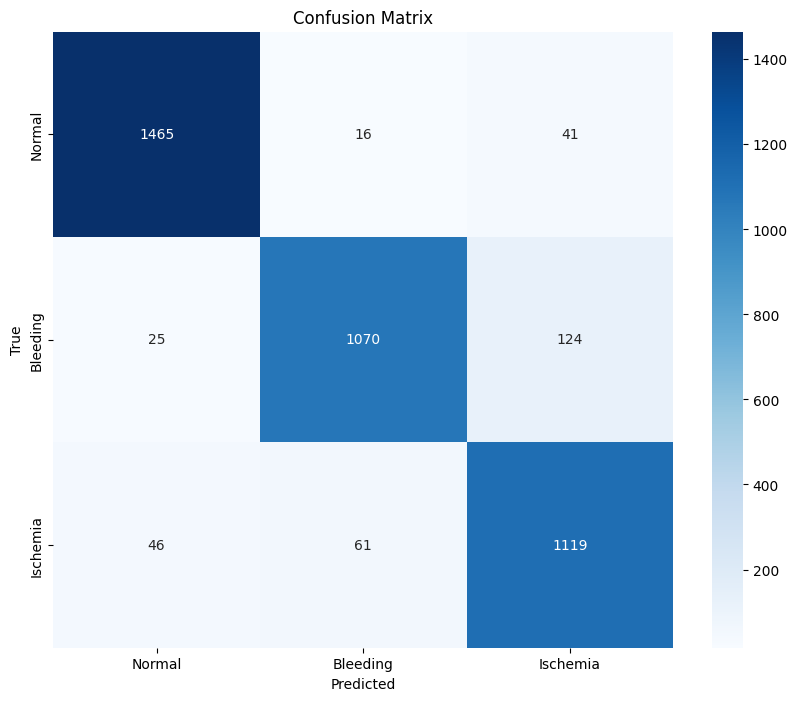


Epoch 11/20


Training:   0%|          | 0/992 [00:00<?, ?it/s]

Validating:   0%|          | 0/248 [00:00<?, ?it/s]

Train Loss: 0.1917, Train Acc: 0.9236
Val Loss: 0.2664, Val Acc: 0.8987

Epoch 12/20


Training:   0%|          | 0/992 [00:00<?, ?it/s]

Validating:   0%|          | 0/248 [00:00<?, ?it/s]

Train Loss: 0.1717, Train Acc: 0.9313
Val Loss: 0.1867, Val Acc: 0.9319
Saved new best model!

Classification Report:
              precision    recall  f1-score   support

      Normal       0.95      0.98      0.97      1522
    Bleeding       0.94      0.90      0.92      1219
    Ischemia       0.91      0.90      0.90      1226

    accuracy                           0.93      3967
   macro avg       0.93      0.93      0.93      3967
weighted avg       0.93      0.93      0.93      3967



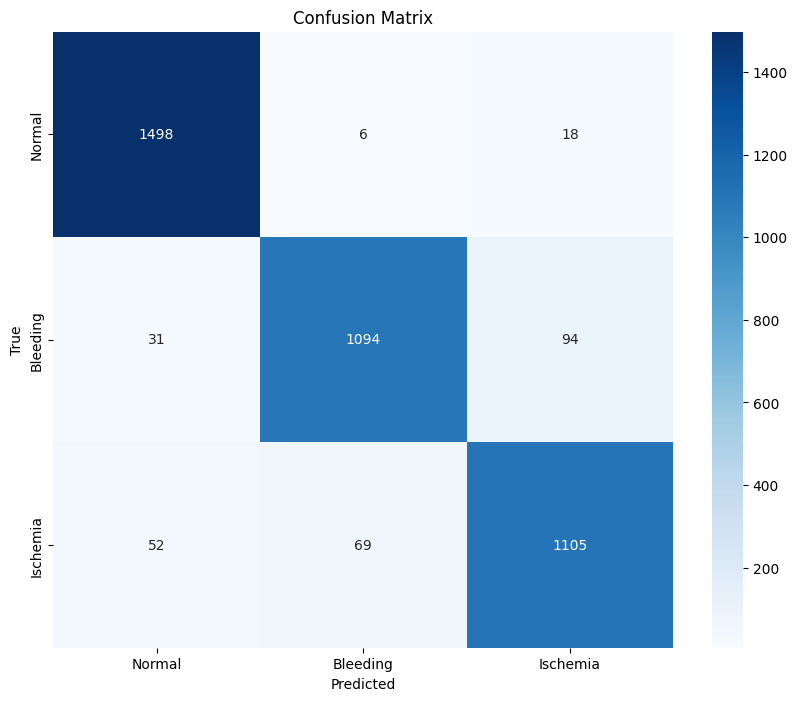


Epoch 13/20


Training:   0%|          | 0/992 [00:00<?, ?it/s]

Validating:   0%|          | 0/248 [00:00<?, ?it/s]

Train Loss: 0.1639, Train Acc: 0.9348
Val Loss: 0.1830, Val Acc: 0.9269

Epoch 14/20


Training:   0%|          | 0/992 [00:00<?, ?it/s]

Validating:   0%|          | 0/248 [00:00<?, ?it/s]

Train Loss: 0.1547, Train Acc: 0.9372
Val Loss: 0.1728, Val Acc: 0.9327
Saved new best model!

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.96      0.97      1522
    Bleeding       0.91      0.92      0.92      1219
    Ischemia       0.90      0.92      0.91      1226

    accuracy                           0.93      3967
   macro avg       0.93      0.93      0.93      3967
weighted avg       0.93      0.93      0.93      3967



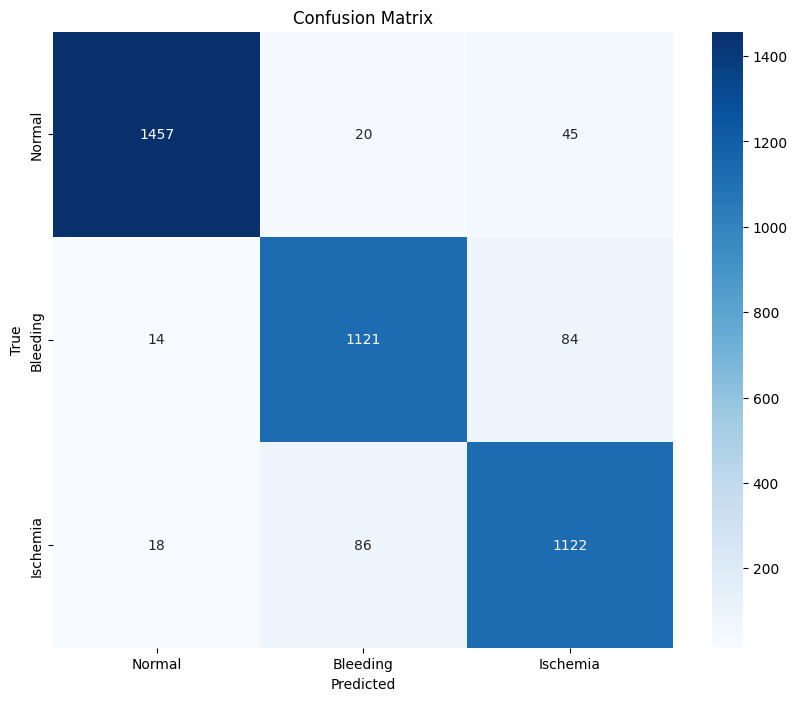


Epoch 15/20


Training:   0%|          | 0/992 [00:00<?, ?it/s]

Validating:   0%|          | 0/248 [00:00<?, ?it/s]

Train Loss: 0.1422, Train Acc: 0.9418
Val Loss: 0.1507, Val Acc: 0.9392
Saved new best model!

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98      1522
    Bleeding       0.93      0.91      0.92      1219
    Ischemia       0.91      0.91      0.91      1226

    accuracy                           0.94      3967
   macro avg       0.94      0.94      0.94      3967
weighted avg       0.94      0.94      0.94      3967



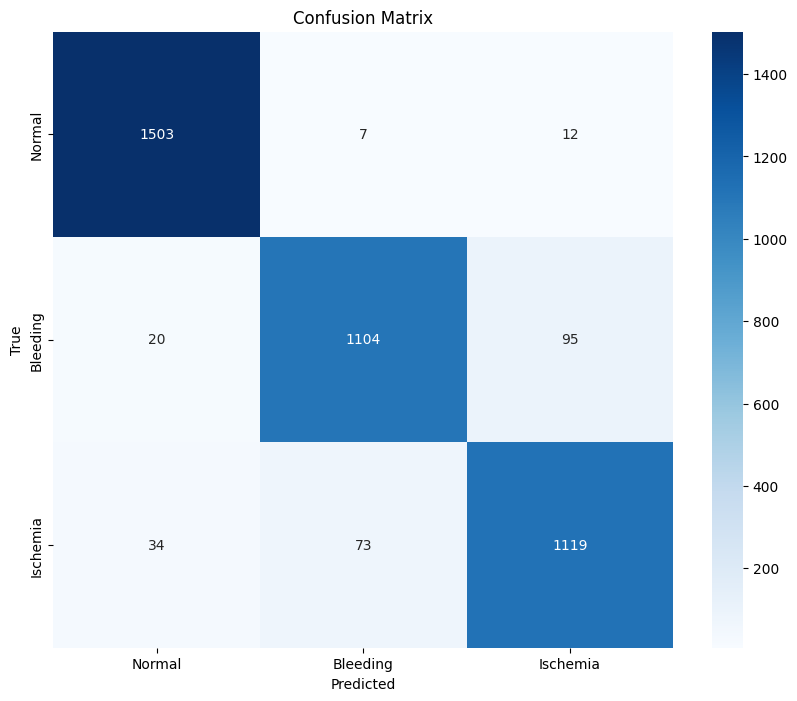


Epoch 16/20


Training:   0%|          | 0/992 [00:00<?, ?it/s]

Validating:   0%|          | 0/248 [00:00<?, ?it/s]

Train Loss: 0.1323, Train Acc: 0.9445
Val Loss: 0.1767, Val Acc: 0.9297

Epoch 17/20


Training:   0%|          | 0/992 [00:00<?, ?it/s]

Validating:   0%|          | 0/248 [00:00<?, ?it/s]

Train Loss: 0.1225, Train Acc: 0.9500
Val Loss: 0.1640, Val Acc: 0.9400
Saved new best model!

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.97      0.97      1522
    Bleeding       0.96      0.89      0.92      1219
    Ischemia       0.88      0.95      0.92      1226

    accuracy                           0.94      3967
   macro avg       0.94      0.94      0.94      3967
weighted avg       0.94      0.94      0.94      3967



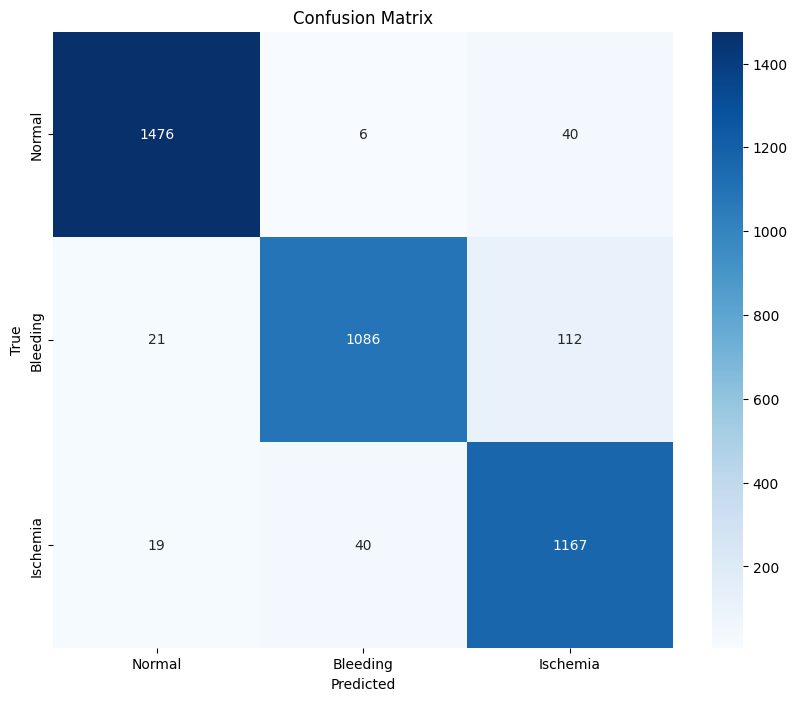


Epoch 18/20


Training:   0%|          | 0/992 [00:00<?, ?it/s]

Validating:   0%|          | 0/248 [00:00<?, ?it/s]

Train Loss: 0.1152, Train Acc: 0.9542
Val Loss: 0.1535, Val Acc: 0.9425
Saved new best model!

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.98      0.98      1522
    Bleeding       0.94      0.91      0.92      1219
    Ischemia       0.91      0.93      0.92      1226

    accuracy                           0.94      3967
   macro avg       0.94      0.94      0.94      3967
weighted avg       0.94      0.94      0.94      3967



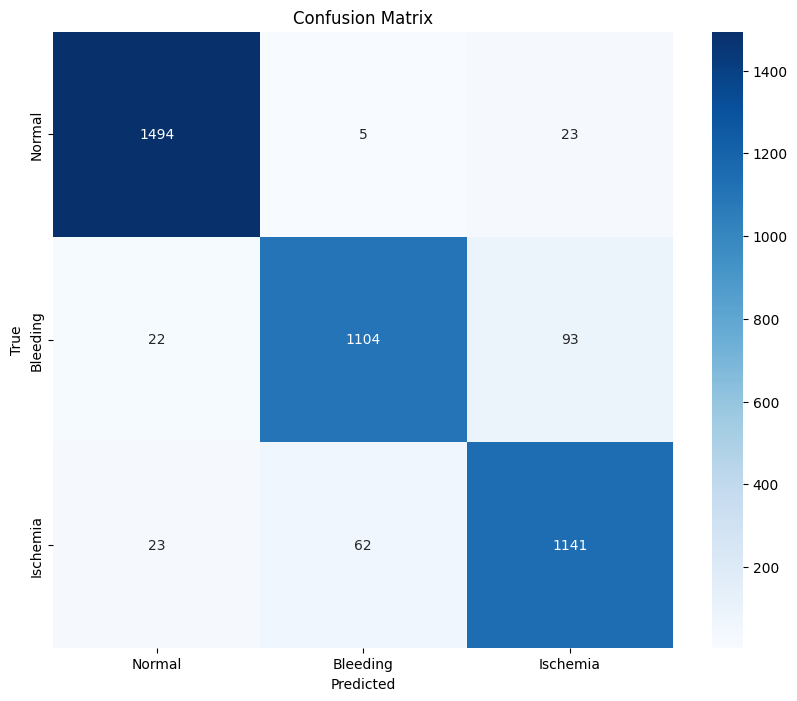


Epoch 19/20


Training:   0%|          | 0/992 [00:00<?, ?it/s]

Validating:   0%|          | 0/248 [00:00<?, ?it/s]

Train Loss: 0.1147, Train Acc: 0.9530
Val Loss: 0.1823, Val Acc: 0.9304

Epoch 20/20


Training:   0%|          | 0/992 [00:00<?, ?it/s]

Validating:   0%|          | 0/248 [00:00<?, ?it/s]

Train Loss: 0.1091, Train Acc: 0.9572
Val Loss: 0.1915, Val Acc: 0.9234


In [16]:
# Training loop
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    
    # Train for one epoch
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Validate
    val_loss, val_acc, all_preds, all_targets = validate(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    # Update learning rate
    scheduler.step(val_acc)
    
    # Print statistics
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_brain_ct_model.pth")
        print("Saved new best model!")
        
        # Detailed metrics for best model
        print("\nClassification Report:")
        print(classification_report(all_targets, all_preds, target_names=class_names))
        
        # Confusion Matrix
        cm = confusion_matrix(all_targets, all_preds)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.title('Confusion Matrix')
        plt.show()

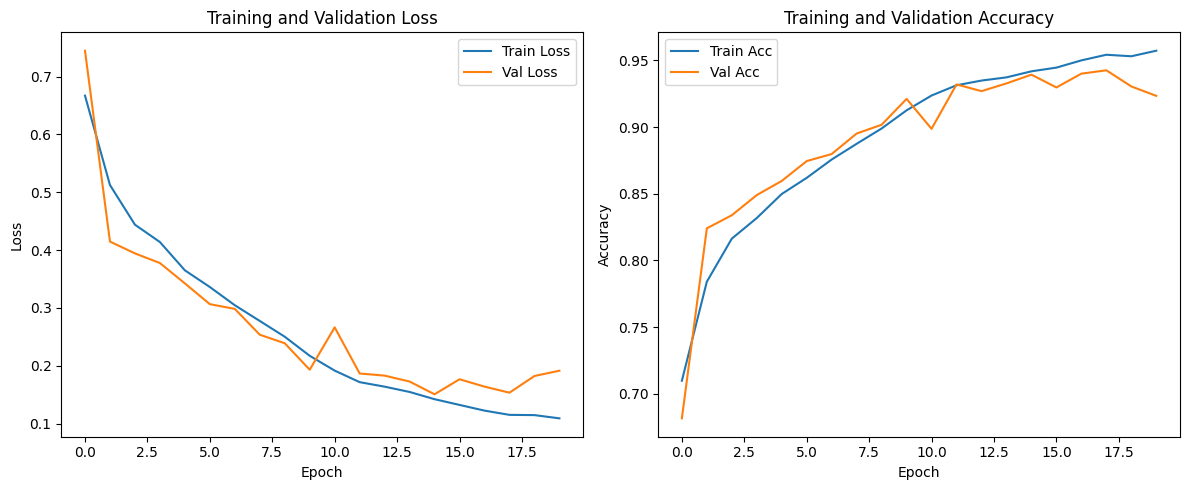

In [17]:
# --------------------------------------------------
# 📊 Training History Visualization
# --------------------------------------------------

# Plot training history
plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


Validating:   0%|          | 0/248 [00:00<?, ?it/s]


Final Validation Accuracy: 0.9425

Final Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.98      0.98      1522
    Bleeding       0.94      0.91      0.92      1219
    Ischemia       0.91      0.93      0.92      1226

    accuracy                           0.94      3967
   macro avg       0.94      0.94      0.94      3967
weighted avg       0.94      0.94      0.94      3967



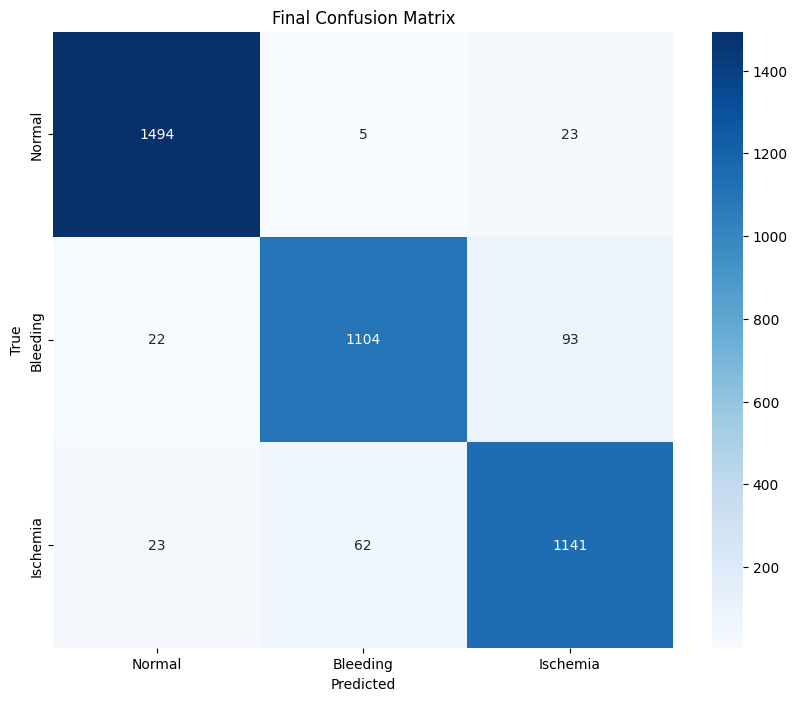

In [18]:
# --------------------------------------------------
# 🔍 Load Best Model and Final Evaluation
# --------------------------------------------------

# Load the best model
model.load_state_dict(torch.load("best_brain_ct_model.pth"))

# Final evaluation
_, final_acc, final_preds, final_targets = validate(model, val_loader, criterion, device)
print(f"\nFinal Validation Accuracy: {final_acc:.4f}")

# Print detailed classification report
print("\nFinal Classification Report:")
print(classification_report(final_targets, final_preds, target_names=class_names))

# Plot confusion matrix
cm = confusion_matrix(final_targets, final_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Final Confusion Matrix')
plt.show()

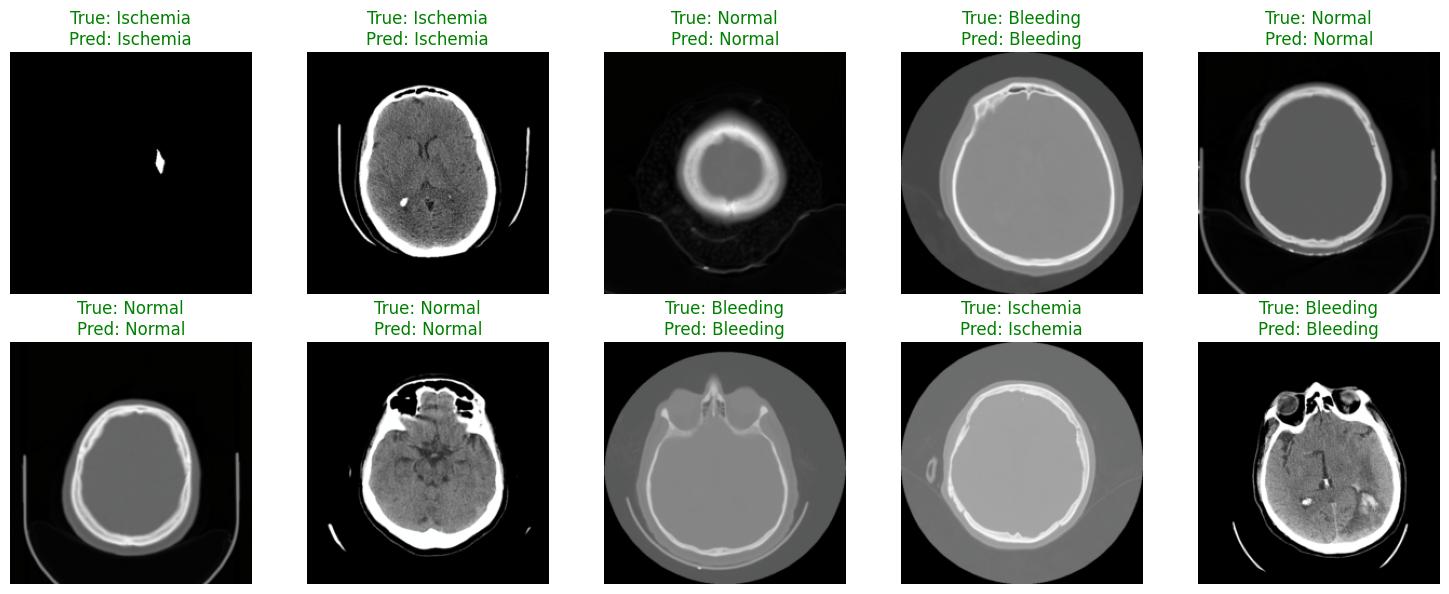

In [19]:
# --------------------------------------------------
# 🖼️ Visualize Model Predictions
# --------------------------------------------------

def visualize_predictions(model, dataloader, class_names, num_samples=10):
    model.eval()
    all_images = []
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, preds = outputs.max(1)
            
            # Store batch data
            all_images.extend(inputs.cpu())
            all_labels.extend(targets.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            
            if len(all_images) >= num_samples:
                break
    
    # Limit to requested number of samples
    all_images = all_images[:num_samples]
    all_labels = all_labels[:num_samples]
    all_preds = all_preds[:num_samples]
    
    # Visualize
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    
    for i, (img, label, pred) in enumerate(zip(all_images, all_labels, all_preds)):
        if i >= len(axes):
            break
            
        # Denormalize image
        img = img.permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        # Display
        axes[i].imshow(img)
        color = 'green' if label == pred else 'red'
        axes[i].set_title(f"True: {class_names[label]}\nPred: {class_names[pred]}", color=color)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualize some predictions
visualize_predictions(model, val_loader, class_names)


Evaluating model on external test set...
Found 200 images in external test set


Predicting:   0%|          | 0/13 [00:00<?, ?it/s]

CSV file content preview:
image_id,Stroke
10189,0
10200,0
10231,0
10267,0
10300,0
10301,0
10319,0
10360,0
10467,0
10493,0
10494,0
10641,0
10693,0
10833,0
10910,0
10911,0
10917,0
10923,0
11023,0
11072,0
11308,0
11319,0
11465,0
...
CSV columns: ['image_id', 'Stroke']
First few rows:
   image_id  Stroke
0     10189       0
1     10200       0
2     10231       0
3     10267       0
4     10300       0
Matched 200 images with labels

External Test Accuracy: 0.9450

External Test Classification Report:
              precision    recall  f1-score   support

      Normal       0.95      0.97      0.96       130
    Abnormal       0.94      0.90      0.92        70

    accuracy                           0.94       200
   macro avg       0.94      0.93      0.94       200
weighted avg       0.94      0.94      0.94       200



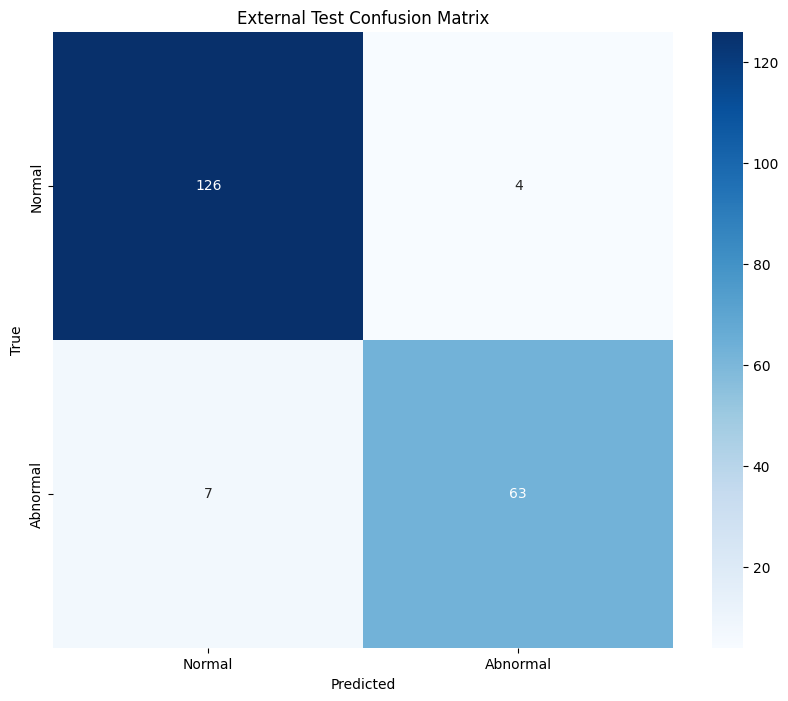

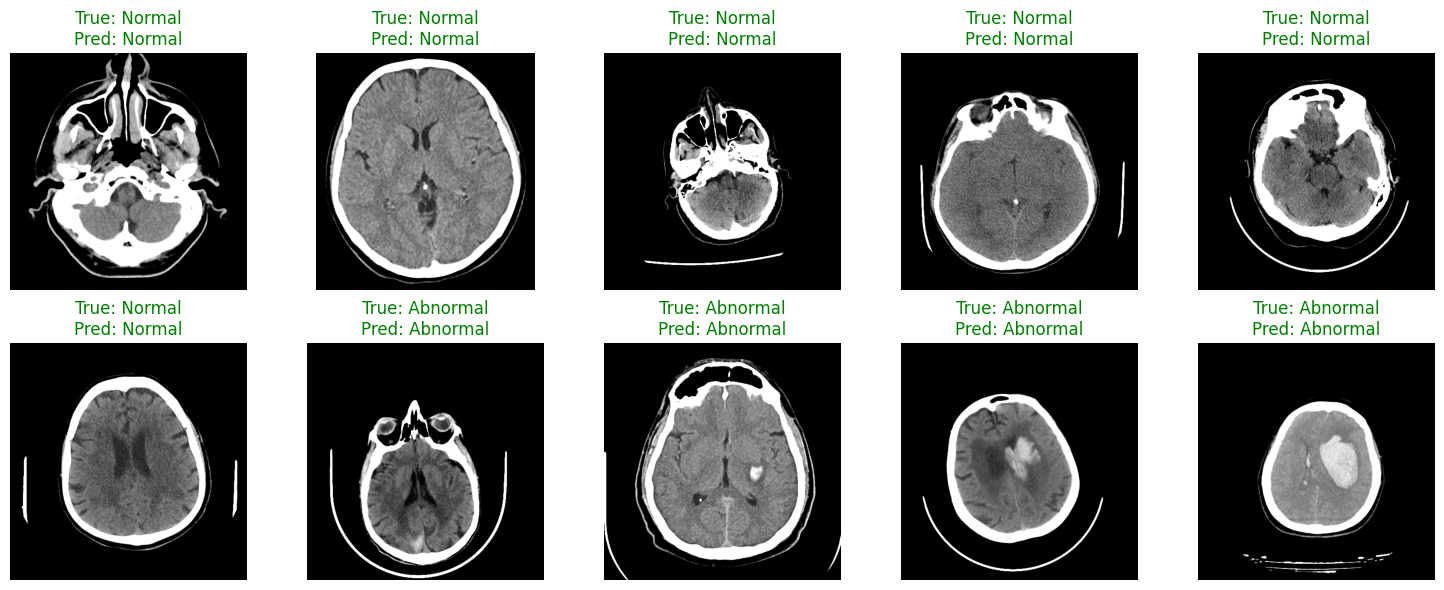


Incorrect Predictions:
File: 11465.png, True: Normal, Pred: Abnormal
File: 12018.png, True: Normal, Pred: Abnormal
File: 15405.png, True: Normal, Pred: Abnormal
File: 15517.png, True: Normal, Pred: Abnormal
File: 11963.png, True: Abnormal, Pred: Normal
File: 11104.png, True: Abnormal, Pred: Normal
File: 13446.png, True: Abnormal, Pred: Normal
File: 13447.png, True: Abnormal, Pred: Normal
File: 14183.png, True: Abnormal, Pred: Normal
File: 15464.png, True: Abnormal, Pred: Normal


In [20]:
# Testing on External Test Set
external_test_path = os.path.join(dataset_path, "External_Test", "PNG")
if os.path.exists(external_test_path):
    print("\nEvaluating model on external test set...")
    
    # Load all test images
    test_images = glob.glob(os.path.join(external_test_path, "*.png"))
    print(f"Found {len(test_images)} images in external test set")
    
    # Create a dataset without labels (we'll add them later)
    class ImageOnlyDataset(Dataset):
        def __init__(self, image_paths, transform=None):
            self.image_paths = image_paths
            self.transform = transform
            
        def __len__(self):
            return len(self.image_paths)
        
        def __getitem__(self, idx):
            img_path = self.image_paths[idx]
            image = Image.open(img_path).convert('RGB')
            
            if self.transform:
                image = self.transform(image)
            else:
                image = torch.tensor(np.array(image)).permute(2, 0, 1).float() / 255.0
                
            return image, os.path.basename(img_path)  # Return image and filename
    
    # Create dataset and dataloader
    test_dataset = ImageOnlyDataset(test_images, transform=transform_val)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    
    # Get predictions for all images
    model.eval()
    all_filenames = []
    all_predictions = []
    all_raw_outputs = []
    
    with torch.no_grad():
        for images, filenames in tqdm(test_loader, desc="Predicting"):
            images = images.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)
            
            # Store results
            all_filenames.extend(filenames)
            all_predictions.extend(preds.cpu().numpy())
            all_raw_outputs.extend(outputs.cpu().numpy())
    
    # Create a dictionary of predictions
    prediction_dict = {filename: pred for filename, pred in zip(all_filenames, all_predictions)}
    
    # Try to load and parse the CSV
    labels_path = os.path.join(dataset_path, "External_Test", "labels.csv")
    if os.path.exists(labels_path):
        # Try to read the CSV file directly
        with open(labels_path, 'r') as f:
            csv_content = f.read()
            print("CSV file content preview:")
            print(csv_content[:200] + "..." if len(csv_content) > 200 else csv_content)
        
        # Load labels
        labels_df = pd.read_csv(labels_path)
        print("CSV columns:", labels_df.columns.tolist())
        print("First few rows:")
        print(labels_df.head())
        
        # Extract image IDs and labels
        # Assuming format is like "10189,0" in a single column
        if ',' in str(labels_df.iloc[0, 0]):
            # Split by comma
            labels_df['image_id'] = labels_df.iloc[:, 0].str.split(',').str[0]
            labels_df['label'] = labels_df.iloc[:, 0].str.split(',').str[1].astype(float).astype(int)
        else:
            # Assume first column is ID, second is label
            labels_df['image_id'] = labels_df.iloc[:, 0]
            labels_df['label'] = labels_df.iloc[:, 1]
        
        # Match predictions with ground truth
        matched_files = []
        true_labels = []
        pred_labels = []
        
        for idx, row in labels_df.iterrows():
            image_id = str(row['image_id'])
            true_label = int(row['label'])
            
            # Find corresponding image file
            matched_file = None
            
            # Try exact match first
            exact_matches = [f for f in all_filenames if image_id in f]
            if exact_matches:
                matched_file = exact_matches[0]
            
            if matched_file:
                matched_files.append(matched_file)
                true_labels.append(true_label)
                pred_labels.append(prediction_dict[matched_file])
        
        print(f"Matched {len(matched_files)} images with labels")
        
        if len(matched_files) > 0:
            # Convert labels for evaluation (0=Normal, 1=Abnormal)
            # Our model predicts 0=Normal, 1=Bleeding, 2=Ischemia
            # Map 1 and 2 to "Abnormal" (1) for binary evaluation
            binary_preds = [0 if p == 0 else 1 for p in pred_labels]
            
            # Calculate metrics
            accuracy = accuracy_score(true_labels, binary_preds)
            binary_class_names = ['Normal', 'Abnormal']
            
            print(f"\nExternal Test Accuracy: {accuracy:.4f}")
            print("\nExternal Test Classification Report:")
            print(classification_report(true_labels, binary_preds, target_names=binary_class_names))
            
            # Plot confusion matrix
            cm = confusion_matrix(true_labels, binary_preds)
            plt.figure(figsize=(10, 8))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=binary_class_names, yticklabels=binary_class_names)
            plt.xlabel('Predicted')
            plt.ylabel('True')
            plt.title('External Test Confusion Matrix')
            plt.show()
            
            # Visualize some examples
            vis_indices = np.random.choice(len(matched_files), min(10, len(matched_files)), replace=False)
            
            fig, axes = plt.subplots(2, 5, figsize=(15, 6))
            axes = axes.flatten()
            
            for i, idx in enumerate(vis_indices):
                if i >= len(axes):
                    break
                
                # Load and display image
                img_path = os.path.join(external_test_path, matched_files[idx])
                img = Image.open(img_path).convert('RGB')
                
                # Display
                axes[i].imshow(img)
                true_label = true_labels[idx]
                pred_label = binary_preds[idx]
                color = 'green' if true_label == pred_label else 'red'
                axes[i].set_title(f"True: {binary_class_names[true_label]}\nPred: {binary_class_names[pred_label]}", color=color)
                axes[i].axis('off')
            
            plt.tight_layout()
            plt.show()
            
            # List incorrect predictions
            incorrect_indices = [i for i, (t, p) in enumerate(zip(true_labels, binary_preds)) if t != p]
            if incorrect_indices:
                print("\nIncorrect Predictions:")
                for i in incorrect_indices[:min(10, len(incorrect_indices))]:
                    print(f"File: {matched_files[i]}, True: {binary_class_names[true_labels[i]]}, Pred: {binary_class_names[binary_preds[i]]}")
            else:
                print("\nAll predictions are correct!")
        else:
            print("No matches found between images and labels")
    else:
        print("External test set found but no labels.csv file")
else:
    print("External test set not found")

In [21]:
torch.save(model.state_dict(), "resnet_model.pth")